In [1]:
import pandas as pd
import yaml
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

from src.mining.clustering import calculate_clustering_metrics, perform_kmeans, get_cluster_profiles
from src.visualization.plots import plot_elbow_method, plot_cluster_radar

# 1. Đọc Config và Load dữ liệu từ file CSV đã lưu
with open('../configs/params.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Đọc file đã xử lý sạch (Lưu ý: dùng path từ config)
df_final = pd.read_csv(f"../{config['processed_data_path']}")
features = config['clustering']['features']
X = df_final[features]


In [2]:
# 2. Tìm số cụm phù hợp (Ví dụ thử từ 2 đến 8 cụm)
k_range = range(2, 9)
inertia, silhouette = calculate_clustering_metrics(X, k_range)



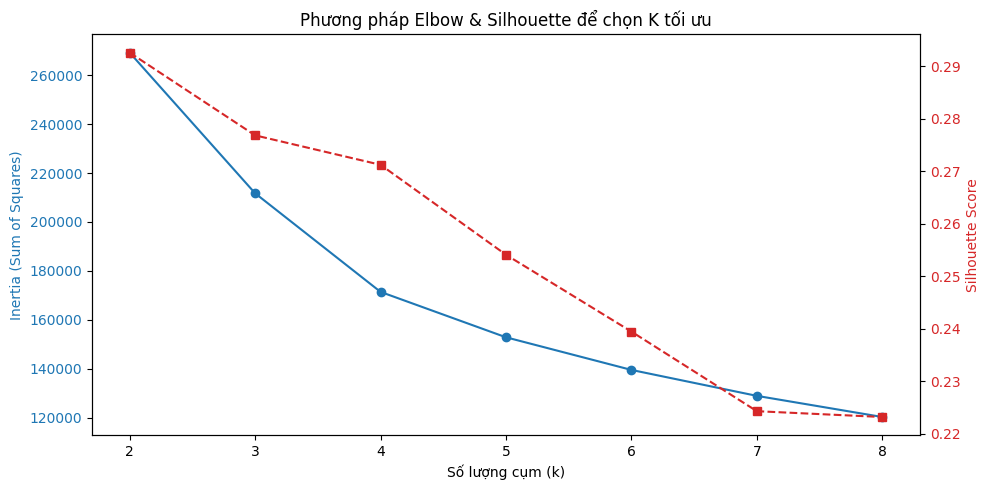

In [3]:
# 3. Vẽ biểu đồ để chọn K
plot_elbow_method(k_range, inertia, silhouette)


In [4]:

best_k = 4 

# 4. Chạy K-Means với k tối ưu
kmeans_model, clusters = perform_kmeans(X, features, n_clusters=best_k)
df_final['Cluster'] = clusters


In [5]:
# 5. Lập Hồ sơ cụm
profile = get_cluster_profiles(df_final, features, 'Cluster')
display(profile)

,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars),Count
Cluster,,,,,
0,-0.295876,-0.085919,1.732251,-0.615416,13631
1,0.018962,0.572522,-0.408838,-0.471409,34350
2,-1.007019,0.559631,-0.398129,1.102732,24486
3,1.168999,-1.342370,0.007497,-0.100886,23986
